<a href="https://colab.research.google.com/github/kdemertzis/EKPA/blob/main/Threat_Hunting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
#εγκατάσταση πακέτου pycaret (https://pycaret.org/)
!pip install pycaret
#***ΠΡΟΣΟΧΗ*** μετά την εγκατάσταση χρειάζεται restart το session

In [44]:
#εισαγωγή βιβλιοθηκών - πακέτων
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.classification import *
from pyod.models.iforest import IForest
import numpy as np

In [47]:
#εισαγωγή του συνόλου δεδομένων
url = "https://raw.githubusercontent.com/kdemertzis/EKPA/refs/heads/main/Data/DarkNet.csv"
df = pd.read_csv(url)
df.shape

(68580, 83)

In [48]:
#ανακάτεμα των δεδομένων
df = df.sample(frac = 1)

In [49]:
#οπτικοποίηση συνόλου δεδομένων
df.head()

,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label-1,Label-2
58252,10.8.8.138,58291,74.125.226.33,443,17,90249137,16,8,5697,2397,...,0,0,0,0,1432490000000000,3.423588e+07,1432490000000000,1432490000000000,VPN,Video-Streaming
40238,10.152.152.11,46984,5.18.157.106,51413,6,467776,3,0,0,0,...,0,0,0,0,0,0.000000e+00,0,0,Non-Tor,P2P
27121,10.152.152.11,43374,173.194.40.158,80,6,104757670,3,4,0,0,...,0,0,0,0,1150410000000000,6.431000e+14,1438020000000000,14600305,Non-Tor,File-Transfer
54355,131.202.240.150,18913,131.202.244.5,53,17,351,1,1,32,82,...,0,0,0,0,0,0.000000e+00,0,0,NonVPN,Video-Streaming
3700,10.152.152.11,57662,93.184.220.29,80,6,421,1,1,0,0,...,0,0,0,0,0,0.000000e+00,0,0,Non-Tor,Browsing


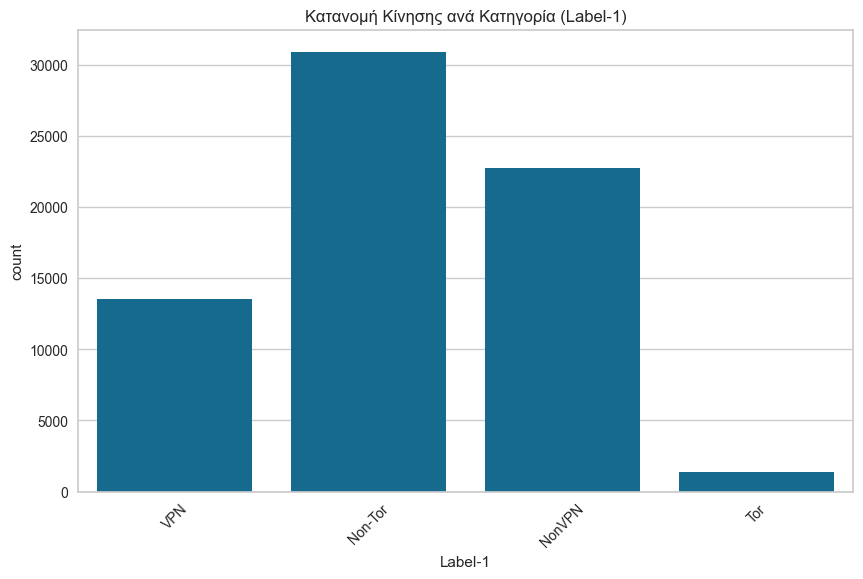

In [50]:
#διερευνητική ανάλυση δεδομένων (EDA): 
#οπτικοποίηση της κατανομής των κλάσεων στο dataset για να εντοπιστούν τυχόν ανισορροπίες
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.countplot(x='Label-1', data=df)
plt.xticks(rotation=45)
plt.title('Κατανομή Κίνησης ανά Κατηγορία (Label-1)')
plt.show()

In [51]:
#καθαρισμός δεδομένων
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [52]:
#διαχωρισμός των δεδομένων σε σύνολα εκπαίδευσης (train) και δοκιμών (test)
train_size = int(0.8 * len(df))
train_df = df[:train_size]
test_df = df[train_size:]

In [53]:
#εκκίνηση της ρύθμισης του PyCaret με προεπεξεργασία δεδομένων
clf_setup = setup(data=df, target='Label-1', session_id=42,
                  normalize=True, transformation=True,
                  ignore_features=['Src_IP', 'Dst_IP', 'Label-2'])

,Description,Value
0,Session id,42
1,Target,Label-1
2,Target type,Multiclass
3,Target mapping,"Non-Tor: 0, NonVPN: 1, Tor: 2, VPN: 3"
4,Original data shape,"(68531, 83)"
5,Transformed data shape,"(68531, 80)"
6,Transformed train set shape,"(47971, 80)"
7,Transformed test set shape,"(20560, 80)"
8,Ignore features,3
9,Numeric features,78


In [54]:
#σύγκριση των διαθέσιμων μοντέλων ΜΜ
best = compare_models(cross_validation=False, n_select = 1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8459,0.9880,0.8459,0.8844,0.8211,0.7550,0.7815,6.5400
knn,K Neighbors Classifier,0.8454,0.9011,0.8454,0.8676,0.8228,0.7539,0.7737,4.9200
rf,Random Forest Classifier,0.8404,0.9888,0.8404,0.8813,0.8086,0.7454,0.7755,7.6500
qda,Quadratic Discriminant Analysis,0.8137,0.9377,0.8137,0.8185,0.8063,0.7089,0.7166,5.2200
svm,SVM - Linear Kernel,0.7749,0.0000,0.7749,0.7783,0.7376,0.6367,0.6568,6.4000
ridge,Ridge Classifier,0.7643,0.0000,0.7643,0.7664,0.7263,0.6178,0.6373,5.0000
lr,Logistic Regression,0.7600,0.9104,0.7600,0.7871,0.7245,0.6157,0.6419,12.4200
lda,Linear Discriminant Analysis,0.7494,0.9176,0.7494,0.7604,0.7129,0.5986,0.6202,5.3000
gbc,Gradient Boosting Classifier,0.7368,0.9057,0.7368,0.8349,0.7099,0.5830,0.6350,204.0400
ada,Ada Boost Classifier,0.7223,0.8360,0.7223,0.7416,0.6993,0.5662,0.5990,16.2800


In [55]:
#αναφορά των υπερπαραμέτρων του μοντέλου με την υψηλότερη απόδοση
print(best)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)


In [56]:
#μέτρα αξιολόγησης του μοντέλου με την υψηλότερη απόδοση
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [57]:
#χρήση Isolation Forest με ποσοστό μόλυνσης (contamination) 10%.
iforest = IForest(contamination=0.1)
iforest = IForest(contamination=0.1)

In [58]:
#εκπαίδευση iForest
iforest.fit(train_df[['Flow_Duration']]) 

IForest(behaviour='old', bootstrap=False, contamination=0.1, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=None,
    verbose=0)

In [59]:
#πρόβλεψη ανωμαλιών
predictions = iforest.predict(test_df[['Flow_Duration']])

In [60]:
#πίνακας προβλέψεων με ανωμαλίες στο σύνολο δοκιμών
test_df['anomaly'] = iforest.predict(test_df[['Flow_Duration']])

In [61]:
#δημιουργία νέας στήλης 'Label' με βάση το αποτέλεσμα του ελέγχου ανίχνευσης ανωμαλιών
test_df['Label'] = test_df['anomaly'].apply(lambda x: 'Anomaly' if x == 1 else 'Normal')

In [62]:
#εκτύπωση των ανωμαλιών
print("Ανωμαλίες στο Test Set:")
print(test_df[test_df['anomaly'] == 1][['Flow_Duration', 'Label']])

Ανωμαλίες στο Test Set:
       Flow_Duration    Label
42751      118306041  Anomaly
4295       117136582  Anomaly
4971        64653243  Anomaly
65492      119101492  Anomaly
21353       71762579  Anomaly
...              ...      ...
9268        24933863  Anomaly
40397       25778401  Anomaly
67435       98997844  Anomaly
35773       82636858  Anomaly
28693       57105916  Anomaly

[1418 rows x 2 columns]


In [63]:
#κατανομή των προβλέψεων για το σύνολο δοκιμών
total_test_samples = len(test_df)
normal_test_samples = len(test_df[test_df['Label'] == 'Normal'])
anomaly_test_samples = len(test_df[test_df['Label'] == 'Anomaly'])

print(f"\nΣύνολο Δοκιμών (Test Set): {total_test_samples}")
print(f"Φυσιολογικές Προβλέψεις: {normal_test_samples}")
print(f"Ανώμαλες Προβλέψεις: {anomaly_test_samples}")
print(f"Ποσοστό Ανωμαλιών: {(anomaly_test_samples / total_test_samples) * 100:.2f}%")


Σύνολο Δοκιμών (Test Set): 13707
Φυσιολογικές Προβλέψεις: 12289
Ανώμαλες Προβλέψεις: 1418
Ποσοστό Ανωμαλιών: 10.35%
